# scNanoSeq MH 5+ indels — HRD tumour vs non-tumour vs non-HRD
**Panel b**: MH 5+ indel fraction per sample (cells with >10 total indels), grouped into tumour cells, non-tumour cells [HRDScout<0.7] and all cells of non-HRD samples.
**Panel c**: pooled ID83 indel spectra for BTT4 tumour and non-tumour cells.
All values are read from `SupTable16_scNanoSeq_MHindel_fractions.xlsx`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.transforms import blended_transform_factory
from scipy import stats

plt.rcParams.update({'pdf.fonttype': 42, 'font.family': 'sans-serif', 'font.size': 7,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.linewidth': 0.5})

TABLE = '../supplemental_tables_v2/SupTable16_scNanoSeq_MHindel_fractions.xlsx'
OUT_DIR = '../output/SuppFig_scNanoSeq_MHindel_spectra'
os.makedirs(OUT_DIR, exist_ok=True)

frac = pd.read_excel(TABLE, sheet_name='MH5 indel fractions')
spectra = pd.read_excel(TABLE, sheet_name='Pooled ID83 spectra')

### Panel b — MH 5+ indel fraction per sample

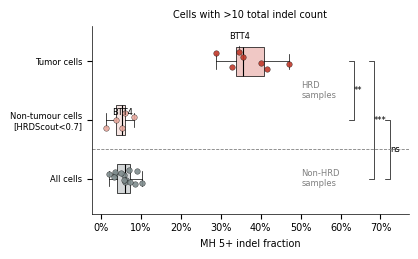

In [2]:
GROUPS = ['HRD tumour', 'HRD non-tumour', 'Non-HRD']
LABELS = ['Tumor cells', 'Non-tumour cells\n[HRDScout<0.7]', 'All cells']
FILL = {'HRD tumour': '#F0C8C5', 'HRD non-tumour': '#F8E6E3', 'Non-HRD': '#D5D8D9'}
DOT = {'HRD tumour': '#C0392B', 'HRD non-tumour': '#E8A89C', 'Non-HRD': '#7F8C8D'}

vals = {g: frac.loc[frac['group'] == g, 'mh5_fraction'].dropna().values for g in GROUPS}

def sig(a, b):
    _, p = stats.mannwhitneyu(vals[a], vals[b], alternative='two-sided')
    return 'ns' if p >= 0.05 else '*' * (1 + (p < 0.01) + (p < 0.001))

fig, ax = plt.subplots(figsize=(4.2, 2.6))
for i, g in enumerate(GROUPS):
    sub = frac[frac['group'] == g].dropna(subset=['mh5_fraction'])
    v = sub['mh5_fraction'].values
    ax.boxplot(v, positions=[i], widths=0.5, patch_artist=True, showfliers=False, vert=False,
               medianprops=dict(color='black', linewidth=0.8),
               boxprops=dict(facecolor=FILL[g], edgecolor='black', linewidth=0.5),
               whiskerprops=dict(color='black', linewidth=0.5),
               capprops=dict(color='black', linewidth=0.5))
    jit = np.random.default_rng(i).uniform(-0.16, 0.16, len(v))
    ax.scatter(v, np.full(len(v), i) + jit, color=DOT[g], s=16, alpha=0.9,
               zorder=3, linewidths=0.25, edgecolors='black')
    for x, y in zip(sub.loc[sub['sample'] == 'BTT4', 'mh5_fraction'],
                    jit[sub['sample'].values == 'BTT4']):
        ax.annotate('BTT4', xy=(x, i + y), xytext=(0, 10), textcoords='offset points',
                    fontsize=6, ha='center', arrowprops=dict(arrowstyle='-', lw=0.4))

xmax = frac['mh5_fraction'].max()
def bracket(y0, y1, x, label):
    h = 0.012
    ax.plot([x, x + h, x + h, x], [y0, y0, y1, y1], lw=0.5, color='k')
    ax.text(x + h, (y0 + y1) / 2, label, ha='left', va='center', fontsize=6)
bracket(0, 1, xmax + 0.15, sig('HRD tumour', 'HRD non-tumour'))
bracket(1, 2, xmax + 0.24, sig('HRD non-tumour', 'Non-HRD'))
bracket(0, 2, xmax + 0.20, sig('HRD tumour', 'Non-HRD'))

ax.axhline(1.5, color='grey', ls='--', lw=0.6)
ax.text(xmax + 0.03, 0.5, 'HRD\nsamples', color='grey', fontsize=6, va='center')
ax.text(xmax + 0.03, 2.0, 'Non-HRD\nsamples', color='grey', fontsize=6, va='center')
ax.set_xlim(right=xmax + 0.30)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(LABELS, fontsize=6)
ax.set_xlabel('MH 5+ indel fraction')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_ylim(-0.6, 2.6)
ax.invert_yaxis()
ax.set_title('Cells with >10 total indel count', fontsize=7)
fig.tight_layout()
fig.savefig(f'{OUT_DIR}/PanelB_MH5_indel_fraction.pdf', bbox_inches='tight')
plt.show()

### Panel c — pooled ID83 spectra (BTT4)

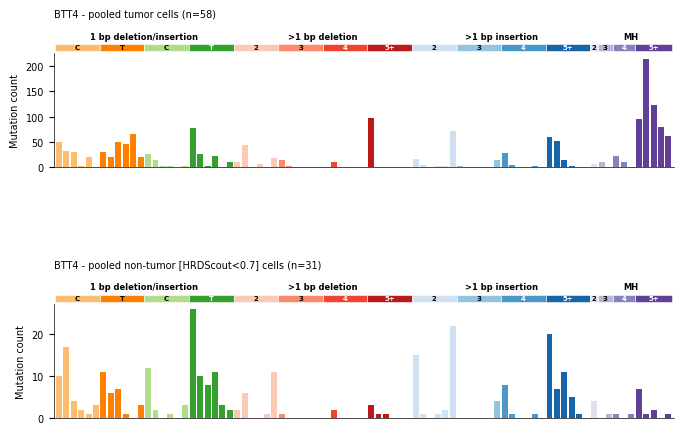

In [3]:
ID83_SUBCATS = [
    ('C', -0.5, 5.5, '#FCBD6F', 'black'), ('T', 5.5, 11.5, '#FD8001', 'black'),
    ('C', 11.5, 17.5, '#B0DC8B', 'black'), ('T', 17.5, 23.5, '#35A02E', 'white'),
    ('2', 23.5, 29.5, '#FCC9B4', 'black'), ('3', 29.5, 35.5, '#FC896B', 'black'),
    ('4', 35.5, 41.5, '#F04432', 'white'), ('5+', 41.5, 47.5, '#BC1A1A', 'white'),
    ('2', 47.5, 53.5, '#CFE0F0', 'black'), ('3', 53.5, 59.5, '#94C3DF', 'black'),
    ('4', 59.5, 65.5, '#4A98C8', 'white'), ('5+', 65.5, 71.5, '#1665AA', 'white'),
    ('2', 71.5, 72.5, '#E1E0ED', 'black'), ('3', 72.5, 74.5, '#B5B5D8', 'black'),
    ('4', 74.5, 77.5, '#8683BC', 'white'), ('5+', 77.5, 82.5, '#624099', 'white'),
]
ID83_TOPCATS = [
    ('1 bp deletion/insertion', -0.5, 23.5), ('>1 bp deletion', 23.5, 47.5),
    ('>1 bp insertion', 47.5, 71.5), ('MH', 71.5, 82.5),
]
CHANNELS = [c for c in spectra.columns if c not in ('sample', 'group', 'n_cells')]
BAR_COLORS = [next(f for _, a, b, f, _t in ID83_SUBCATS if a <= i < b) for i in range(83)]

def plot_spectrum(ax, counts, title):
    ax.bar(range(83), counts, color=BAR_COLORS, width=0.8, linewidth=0)
    ax.set_xlim(-0.7, 82.7)
    ax.set_xticks([])
    ax.set_ylabel('Mutation count')
    ax.set_title('')
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for label, x0, x1, fill, tc in ID83_SUBCATS:
        ax.add_patch(mpatches.Rectangle((x0, 1.02), x1 - x0, 0.06, facecolor=fill,
                     edgecolor='white', linewidth=0.4, transform=trans, clip_on=False, zorder=5))
        ax.text((x0 + x1) / 2, 1.05, label, ha='center', va='center', fontsize=5,
                color=tc, fontweight='bold', transform=trans, clip_on=False, zorder=6)
    for label, x0, x1 in ID83_TOPCATS:
        ax.text((x0 + x1) / 2, 1.15, label, ha='center', va='center', fontsize=6,
                fontweight='bold', transform=trans, clip_on=False)
    ax.text(0.0, 1.30, title, transform=ax.transAxes, fontsize=7, va='bottom')

fig, axes = plt.subplots(2, 1, figsize=(8, 4.8))
for ax, group in zip(axes, ['HRD tumour', 'HRD non-tumour']):
    row = spectra[(spectra['sample'] == 'BTT4') & (spectra['group'] == group)].iloc[0]
    tag = 'tumor' if group == 'HRD tumour' else 'non-tumor [HRDScout<0.7]'
    plot_spectrum(ax, row[CHANNELS].values.astype(float),
                  f"BTT4 - pooled {tag} cells (n={int(row['n_cells'])})")
fig.subplots_adjust(hspace=1.2, top=0.84, bottom=0.08)
fig.savefig(f'{OUT_DIR}/PanelC_BTT4_ID83_spectra.pdf', bbox_inches='tight')
plt.show()